### Notebook de testes para encontrar o melhor backtest do modelo

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import requests
import seaborn as sns


from funcoes import (
    pca_portfolio_spy,
    stats_from_returns,
)

In [3]:
# Carregar dados
data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')
start_date = "1997-01-02"
end_date = "2007-12-31"

data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True,axis=0, how='all')
returns_spy.dropna(inplace=True,axis=1, how='any')

# Garantir que ambos os DataFrames tenham
# índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

[*********************100%***********************]  1 of 1 completed


Tempo : 1998-01-02 00:00:00
Tempo : 1998-01-05 00:00:00
Tempo : 1998-01-06 00:00:00
Tempo : 1998-01-07 00:00:00
Tempo : 1998-01-08 00:00:00
Tempo : 1998-01-09 00:00:00
Tempo : 1998-01-12 00:00:00
Tempo : 1998-01-13 00:00:00
Tempo : 1998-01-14 00:00:00
Tempo : 1998-01-15 00:00:00
Tempo : 1998-01-16 00:00:00
Tempo : 1998-01-20 00:00:00
Tempo : 1998-01-21 00:00:00
Tempo : 1998-01-22 00:00:00
Tempo : 1998-01-23 00:00:00
Tempo : 1998-01-26 00:00:00
Tempo : 1998-01-27 00:00:00
Tempo : 1998-01-28 00:00:00
Tempo : 1998-01-29 00:00:00
Tempo : 1998-01-30 00:00:00
Tempo : 1998-02-02 00:00:00
Tempo : 1998-02-03 00:00:00
Tempo : 1998-02-04 00:00:00
Tempo : 1998-02-05 00:00:00
Tempo : 1998-02-06 00:00:00
Tempo : 1998-02-09 00:00:00
Tempo : 1998-02-10 00:00:00
Tempo : 1998-02-11 00:00:00
Tempo : 1998-02-12 00:00:00
Tempo : 1998-02-13 00:00:00
Tempo : 1998-02-17 00:00:00
Tempo : 1998-02-18 00:00:00
Tempo : 1998-02-19 00:00:00
Tempo : 1998-02-20 00:00:00
Tempo : 1998-02-23 00:00:00
Tempo : 1998-02-24 0

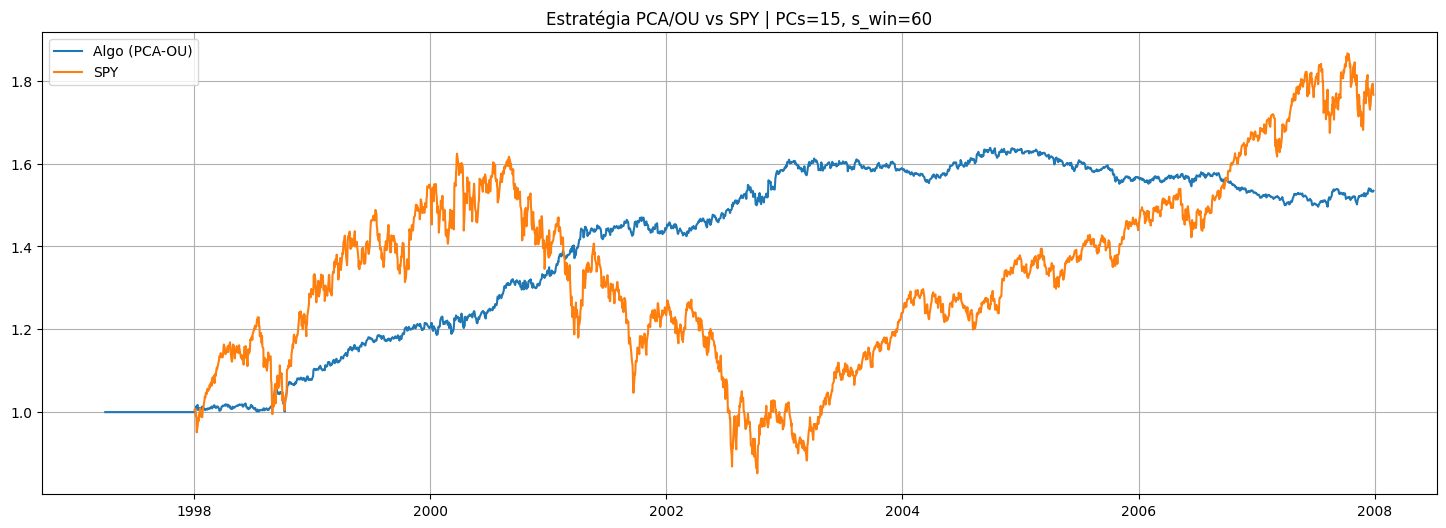

In [4]:
# Rodar experimento 01 : (n = 15, sbo=1.25, sso=1.25, sbc=0.75, ssc=0.50)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=15,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.75,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    plot=True,
)

In [5]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.04072130705132859),
 'Vol': np.float64(0.04546341703779945),
 'Sharpe': np.float64(0.8956939382156834),
 'MaxDD': np.float64(-0.086766833928142)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    1.000000
1997-04-04    1.000000
1997-04-07    1.000000
                ...   
2007-12-21    1.533216
2007-12-24    1.532406
2007-12-26    1.532778
2007-12-27    1.532333
2007-12-28    1.534622
Length: 2705, dtype: float64

Tempo : 1998-01-02 00:00:00
Tempo : 1998-01-05 00:00:00
Tempo : 1998-01-06 00:00:00
Tempo : 1998-01-07 00:00:00
Tempo : 1998-01-08 00:00:00
Tempo : 1998-01-09 00:00:00
Tempo : 1998-01-12 00:00:00
Tempo : 1998-01-13 00:00:00
Tempo : 1998-01-14 00:00:00
Tempo : 1998-01-15 00:00:00
Tempo : 1998-01-16 00:00:00
Tempo : 1998-01-20 00:00:00
Tempo : 1998-01-21 00:00:00
Tempo : 1998-01-22 00:00:00
Tempo : 1998-01-23 00:00:00
Tempo : 1998-01-26 00:00:00
Tempo : 1998-01-27 00:00:00
Tempo : 1998-01-28 00:00:00
Tempo : 1998-01-29 00:00:00
Tempo : 1998-01-30 00:00:00
Tempo : 1998-02-02 00:00:00
Tempo : 1998-02-03 00:00:00
Tempo : 1998-02-04 00:00:00
Tempo : 1998-02-05 00:00:00
Tempo : 1998-02-06 00:00:00
Tempo : 1998-02-09 00:00:00
Tempo : 1998-02-10 00:00:00
Tempo : 1998-02-11 00:00:00
Tempo : 1998-02-12 00:00:00
Tempo : 1998-02-13 00:00:00
Tempo : 1998-02-17 00:00:00
Tempo : 1998-02-18 00:00:00
Tempo : 1998-02-19 00:00:00
Tempo : 1998-02-20 00:00:00
Tempo : 1998-02-23 00:00:00
Tempo : 1998-02-24 0

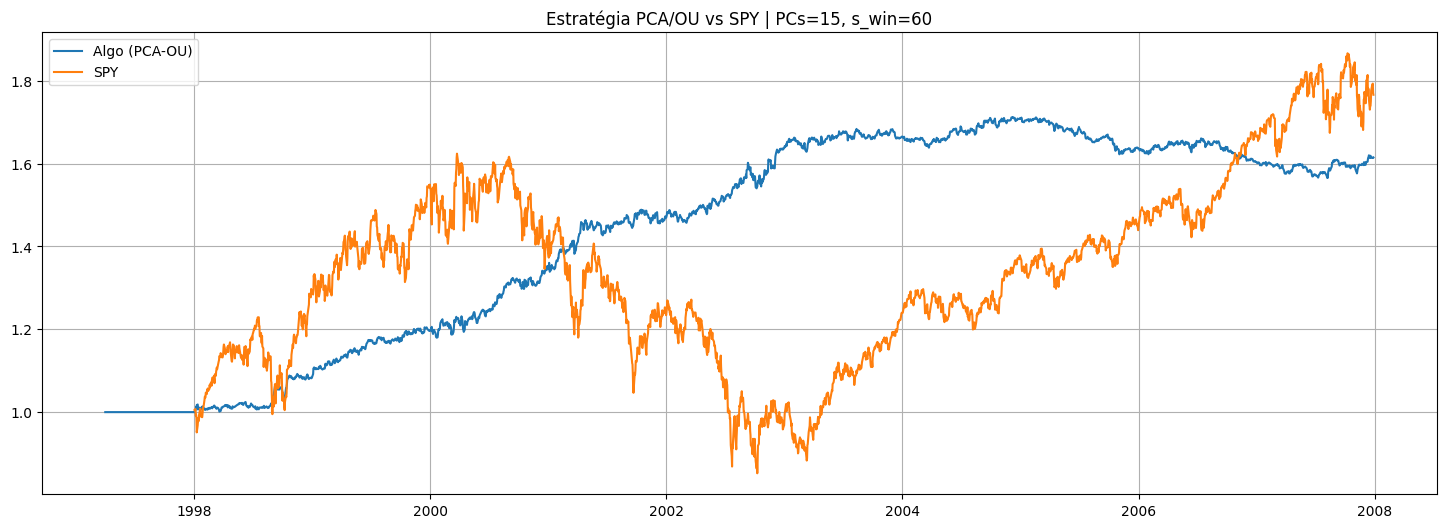

In [6]:
# Rodar experimento 02 : (n = 15, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=15,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    plot=True,
)

In [7]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.045663069805172096),
 'Vol': np.float64(0.04438246178341003),
 'Sharpe': np.float64(1.0288539204519915),
 'MaxDD': np.float64(-0.08547540221928007)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    1.000000
1997-04-04    1.000000
1997-04-07    1.000000
                ...   
2007-12-21    1.614224
2007-12-24    1.613595
2007-12-26    1.614536
2007-12-27    1.613551
2007-12-28    1.614644
Length: 2705, dtype: float64

Tempo : 1998-01-02 00:00:00
Tempo : 1998-01-05 00:00:00
Tempo : 1998-01-06 00:00:00
Tempo : 1998-01-07 00:00:00
Tempo : 1998-01-08 00:00:00
Tempo : 1998-01-09 00:00:00
Tempo : 1998-01-12 00:00:00
Tempo : 1998-01-13 00:00:00
Tempo : 1998-01-14 00:00:00
Tempo : 1998-01-15 00:00:00
Tempo : 1998-01-16 00:00:00
Tempo : 1998-01-20 00:00:00
Tempo : 1998-01-21 00:00:00
Tempo : 1998-01-22 00:00:00
Tempo : 1998-01-23 00:00:00
Tempo : 1998-01-26 00:00:00
Tempo : 1998-01-27 00:00:00
Tempo : 1998-01-28 00:00:00
Tempo : 1998-01-29 00:00:00
Tempo : 1998-01-30 00:00:00
Tempo : 1998-02-02 00:00:00
Tempo : 1998-02-03 00:00:00
Tempo : 1998-02-04 00:00:00
Tempo : 1998-02-05 00:00:00
Tempo : 1998-02-06 00:00:00
Tempo : 1998-02-09 00:00:00
Tempo : 1998-02-10 00:00:00
Tempo : 1998-02-11 00:00:00
Tempo : 1998-02-12 00:00:00
Tempo : 1998-02-13 00:00:00
Tempo : 1998-02-17 00:00:00
Tempo : 1998-02-18 00:00:00
Tempo : 1998-02-19 00:00:00
Tempo : 1998-02-20 00:00:00
Tempo : 1998-02-23 00:00:00
Tempo : 1998-02-24 0

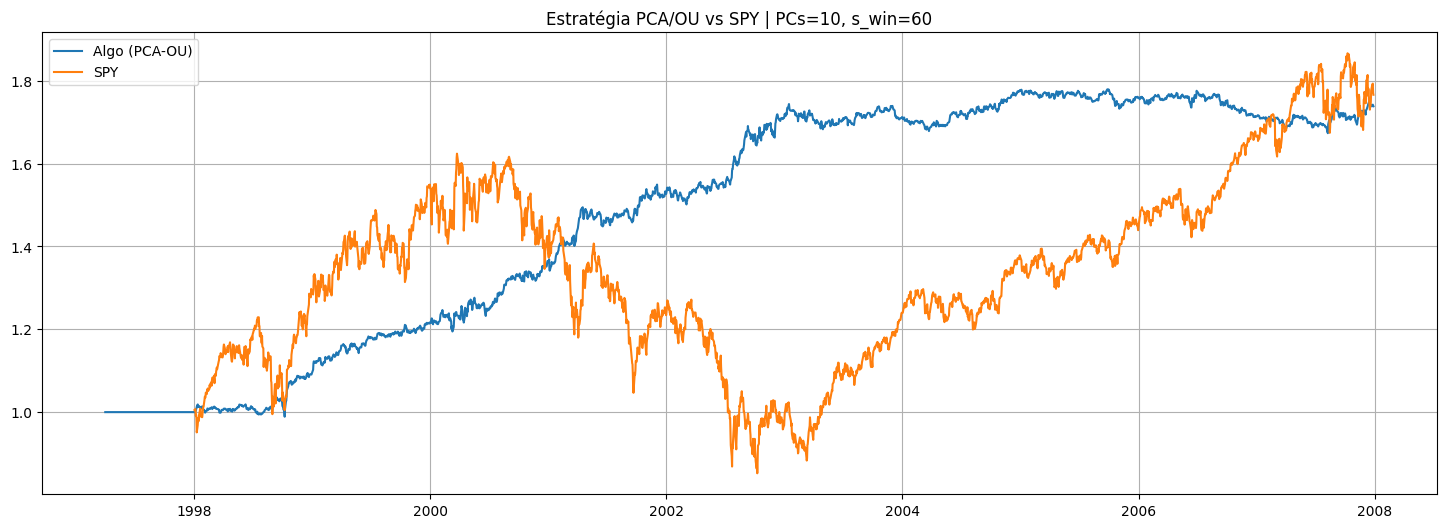

In [8]:
# Rodar experimento 03 : (n = 10, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=10,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    plot=True,
)

In [9]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.05288046477926289),
 'Vol': np.float64(0.04840506212105234),
 'Sharpe': np.float64(1.092457327025392),
 'MaxDD': np.float64(-0.059604451903342515)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    1.000000
1997-04-04    1.000000
1997-04-07    1.000000
                ...   
2007-12-21    1.738270
2007-12-24    1.740840
2007-12-26    1.742299
2007-12-27    1.740461
2007-12-28    1.738325
Length: 2705, dtype: float64

Tempo : 1998-01-02 00:00:00
Tempo : 1998-01-05 00:00:00
Tempo : 1998-01-06 00:00:00
Tempo : 1998-01-07 00:00:00
Tempo : 1998-01-08 00:00:00
Tempo : 1998-01-09 00:00:00
Tempo : 1998-01-12 00:00:00
Tempo : 1998-01-13 00:00:00
Tempo : 1998-01-14 00:00:00
Tempo : 1998-01-15 00:00:00
Tempo : 1998-01-16 00:00:00
Tempo : 1998-01-20 00:00:00
Tempo : 1998-01-21 00:00:00
Tempo : 1998-01-22 00:00:00
Tempo : 1998-01-23 00:00:00
Tempo : 1998-01-26 00:00:00
Tempo : 1998-01-27 00:00:00
Tempo : 1998-01-28 00:00:00
Tempo : 1998-01-29 00:00:00
Tempo : 1998-01-30 00:00:00
Tempo : 1998-02-02 00:00:00
Tempo : 1998-02-03 00:00:00
Tempo : 1998-02-04 00:00:00
Tempo : 1998-02-05 00:00:00
Tempo : 1998-02-06 00:00:00
Tempo : 1998-02-09 00:00:00
Tempo : 1998-02-10 00:00:00
Tempo : 1998-02-11 00:00:00
Tempo : 1998-02-12 00:00:00
Tempo : 1998-02-13 00:00:00
Tempo : 1998-02-17 00:00:00
Tempo : 1998-02-18 00:00:00
Tempo : 1998-02-19 00:00:00
Tempo : 1998-02-20 00:00:00
Tempo : 1998-02-23 00:00:00
Tempo : 1998-02-24 0

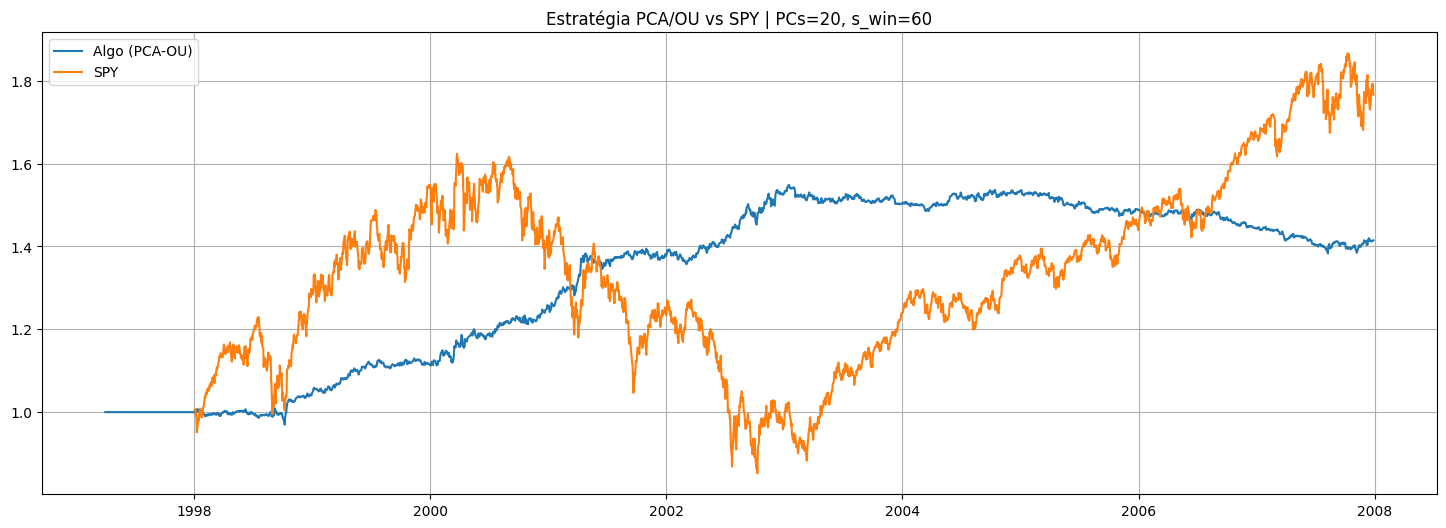

In [10]:
# Rodar experimento 04 : (n = 20, sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50)
cum_algo, s_scores = pca_portfolio_spy(
    returns=returns,
    returns_spy=returns_spy,
    num_pc=20,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    plot=True,
)

In [11]:
# Estatísticas de desempenho
ret_series = cum_algo.pct_change().dropna()
display(stats_from_returns(ret_series))
cum_algo

{'CAGR': np.float64(0.03286904557898618),
 'Vol': np.float64(0.04015351248302837),
 'Sharpe': np.float64(0.8185845657432558),
 'MaxDD': np.float64(-0.10690788245055283)}

Date
1997-04-01    1.000000
1997-04-02    1.000000
1997-04-03    1.000000
1997-04-04    1.000000
1997-04-07    1.000000
                ...   
2007-12-21    1.412189
2007-12-24    1.412698
2007-12-26    1.414412
2007-12-27    1.414321
2007-12-28    1.414842
Length: 2705, dtype: float64

In [12]:
#pip install quantstats

In [ ]:
import quantstats as qs

qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
